In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PARÁMETROS DEL SISTEMA (Articulo fuente: Ordóñez-Romero et al. 2016)
# =================================================================

# Parámetros magnéticos
gamma = 2.8      # Proporción giromagnética (MHz/Oe)
H0 = 770.0       # Campo magnético aplicado (Oe)
Ms = 1750.0      # Magnetización de saturación (Gauss)
deltaH = 0.5     # Ancho de línea FMR (Oe)

# Frecuencias angulares (en rad/ns para consistencia con um y ns)
# Dividimos entre 1000 para pasar de MHz a GHz (1 / 1 GHz ~ 1 ns)
wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM = 2 * np.pi * (gamma * Ms / 1000.0)

# Parámetros geométricos (micrómetros)
dPF = 8.3        # Espesor de la película plana
delta = 1.0      # Profundidad del surco grabado
dG = dPF - delta # Espesor en la región del surco
LPF = 330.0      # Longitud de la región plana
LG = 70.0        # Longitud del surco
Nperiods = 12    # Número total de períodos (surcos)

In [ ]:
# =================================================================
# 2. FUNCIONES DE DISPERSIÓN Y ATENUACIÓN ESPACIAL
# =================================================================

def k_wave(w, d):
    """Calcula el vector de onda real k(w, d) en rad/um"""
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    if arg <= 0:
        return np.nan
    return -(1 / (2 * d)) * np.log(arg)

def v_group(w, d):
    """Calcula la velocidad de grupo vg(w, d) en um/ns"""
    k = k_wave(w, d)
    return (wM**2 * d * np.exp(-2 * k * d)) / (4 * w)

def k_prime(w, d):
    """Calcula la tasa de atenuación espacial k' en rad/um"""
    vg = np.abs(v_group(w, d))

    # Dividimos entre 1000 para que quede  (rad / ns) / (um / ns) = rad / um
    # Al multiplicar por L en um nos queda el argumento de la exponencial en rad
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / vg

In [ ]:
# =================================================================
# 3. CONSTRUCCIÓN DE LAS MATRICES DE TRANSFERENCIA
# =================================================================

# Coeficiente de reflexión por salto de impedancia (aproximación geométrica)
GammaRef = delta / (2 * dPF - delta)

def T_interface(nu):
    """Matriz de interfaz geométrica. nu=+1 (entrada), nu=-1 (salida)"""
    mat = np.array([
        [1.0, nu * GammaRef],
        [nu * GammaRef, 1.0]
    ], dtype=complex)
    return (1.0 / (1.0 - nu * GammaRef)) * mat

def T_prop(w, d, L):
    """Matriz de propagación con atenuación intrínseca"""
    k = k_wave(w, d)
    kp = k_prime(w, d)

    # Acumulación de fase y decaimiento de amplitud
    exp_minus = np.exp(-(1j * k - kp) * L)
    exp_plus  = np.exp((1j * k - kp) * L)

    return np.array([
        [exp_minus, 0.0],
        [0.0, exp_plus]
    ], dtype=complex)

def T_cell(w):
    """Multiplicación de matrices para una Celda Unidad completa"""
    t_pf = T_prop(w, dPF, LPF)
    t_in = T_interface(1)
    t_g  = T_prop(w, dG, LG)
    t_out = T_interface(-1)
    # @ -> multiplicación de matrices en numpy
    return t_pf @ t_in @ t_g @ t_out

def transmission_power(f_GHz):
    """Coeficiente de potencia transmitida Pw para el cristal de N periodos"""
    w = 2 * np.pi * f_GHz
    tc = T_cell(w)
    # Matriz elevada a la potencia N
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    return 1.0 / (np.abs(T11)**2)  # P_tr = 1 / |T_11|^2 = 1 / |T_22|^2

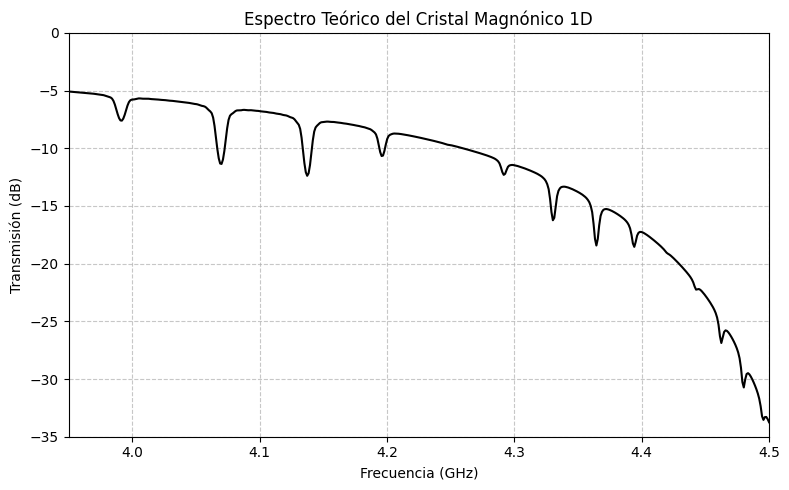

In [ ]:
# =================================================================
# 4. CÁLCULO DEL ESPECTRO
# =================================================================

# Rango de frecuencias
f_min_ghz = 3.95
f_max_ghz = 4.5
f_array = np.linspace(f_min_ghz, f_max_ghz, 500)
trans_db = []

# Evaluar numéricamente cada punto
for f in f_array:
    p_w = transmission_power(f)
    trans_db.append(10 * np.log10(p_w))  # Escala de potencia en decibeles


plt.figure(figsize=(8, 5))
plt.plot(f_array, trans_db, color='black', linewidth=1.5)
plt.title('Espectro Teórico del Cristal Magnónico 1D')
plt.xlabel('Frecuencia (GHz)')
plt.ylabel('Transmisión (dB)')
plt.xlim(f_min_ghz, f_max_ghz)
plt.ylim(-35, 0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Para calcular la curva de disversión, extraemos la traza de nuestra matriz T_cell para aplicar el Teorema de Bloch

$$(cos(KΛ)= \frac{1}{2}​Tr(T_{cell}​))$$

y mapear cómo el vector de onda K se comporta frente a la frecuencia.

In [ ]:
# =================================================================
# 5. CÁLCULO DEL VECTOR DE ONDA DE BLOCH Y ZONAS DE BRILLOUIN
# =================================================================

# Constante de red en micrómetros
Lambda = LPF + LG # 400 um

def K_bloch(f_GHz):
    """
    Calcula la parte real del vector de onda de Bloch K en rad/cm.
    """
    w = 2 * np.pi * f_GHz
    tc = T_cell(w)

    # Extraemos la traza de la matriz de la celda
    tr = np.trace(tc)

    # Aplicamos la ecuación de dispersión: K = arccos(Tr / 2) / Lambda
    # Tomamos la parte real para graficar la fase de propagación.
    K_um = np.real(np.arccos(tr / 2.0)) / Lambda

    # Convertimos de rad/um a rad/cm multiplicando por 10,000
    return K_um * 10000.0

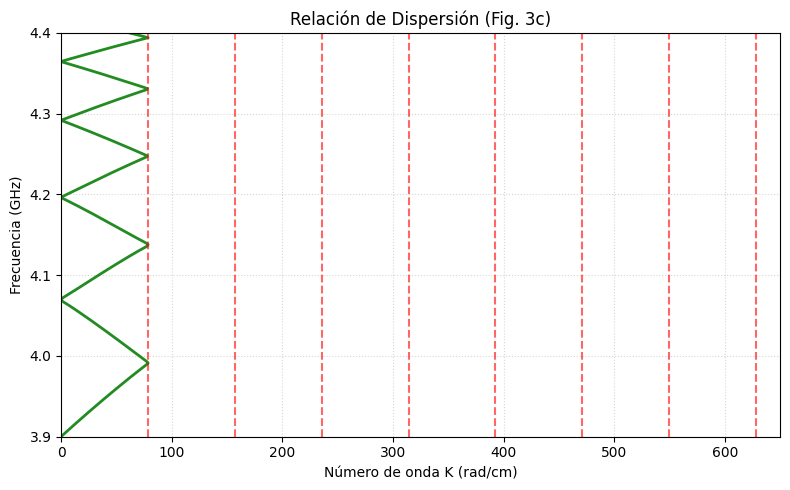

In [ ]:
# =================================================================
# 6. EVALUACIÓN Y GRÁFICA (Dispersión w vs K)
# =================================================================

f_disp_array = np.linspace(3.9, 4.4, 500)

# Evaluamos K para cada frecuencia
K_array = [K_bloch(f) for f in f_disp_array]

# Calculamos las fronteras de las primeras zonas de Brillouin (n * pi / Lambda)
# Y las convertimos a rad/cm (* 10000)
n_zonas = 8
bz_boundaries = [(n * np.pi / Lambda) * 10000.0 for n in range(1, n_zonas + 1)]

plt.figure(figsize=(8, 5))
plt.plot(K_array, f_disp_array, color='forestgreen',
         linewidth=2, label='Dispersión MSSW')

# Añadimos las líneas punteadas rojas para las fronteras de Brillouin
for bz in bz_boundaries:
    if bz <= 650: # Solo graficamos las que caen dentro de nuestro eje X
        plt.axvline(x=bz, color='red', linestyle='--', alpha=0.6)

plt.title('Relación de Dispersión (Fig. 3c)')
plt.xlabel('Número de onda K (rad/cm)')
plt.ylabel('Frecuencia (GHz)')
plt.xlim(0, 650)
plt.ylim(3.9, 4.4)

# Rejilla secundaria para mejor lectura
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Observación: Unwrapping phase

La figura anterior nos muestra la Relación de dispersión graficada en el Esquema de Zona Reducida. Vemos como la curva rebota formando un patrón de zig-zag confinado exactamente dentro de la primera Zona de Brillouin.

Para obtener la grafica en el Esquema de Zona Extendida, donde K crece de forma continua, necesitamos desdoblar la fase ("Unwrapping"). En lugar de graficar el valor crudo del `arccos`, calcularemos el salto entre puntos adyacentes. Como K siempre debe crecer (o quedarse estancado dentro del bandgap), simplemente sumamos el valor absoluto de la diferencia paso a paso.

In [ ]:
# =================================================================
# 5. CÁLCULO DEL VECTOR DE ONDA DE BLOCH (ZONA EXTENDIDA)
# =================================================================

Lambda = LPF + LG

def get_raw_phi(f_GHz):
    """Obtiene la fase principal en el rango [0, pi]"""
    w = 2 * np.pi * f_GHz
    tc = T_cell(w)
    tr = np.trace(tc)
    return np.real(np.arccos(tr / 2.0))

# Vector de frecuencias
f_disp_array = np.linspace(3.9, 4.4, 500)

# Obtenemos los valores con el "zig-zag"
raw_phis = [get_raw_phi(f) for f in f_disp_array]

# Algoritmo para forzar el Esquema de Zona Extendida
K_extended_um = np.zeros(len(f_disp_array))
K_extended_um[0] = raw_phis[0]

for i in range(1, len(f_disp_array)):
    # Calculamos el salto. Al usar np.abs(), cuando el arccos
    # intente doblarse hacia atrás, nosotros lo forzamos hacia adelante.
    d_phi = np.abs(raw_phis[i] - raw_phis[i-1])
    K_extended_um[i] = K_extended_um[i-1] + d_phi

# Convertimos a rad/cm
K_array = (K_extended_um / Lambda) * 10000.0

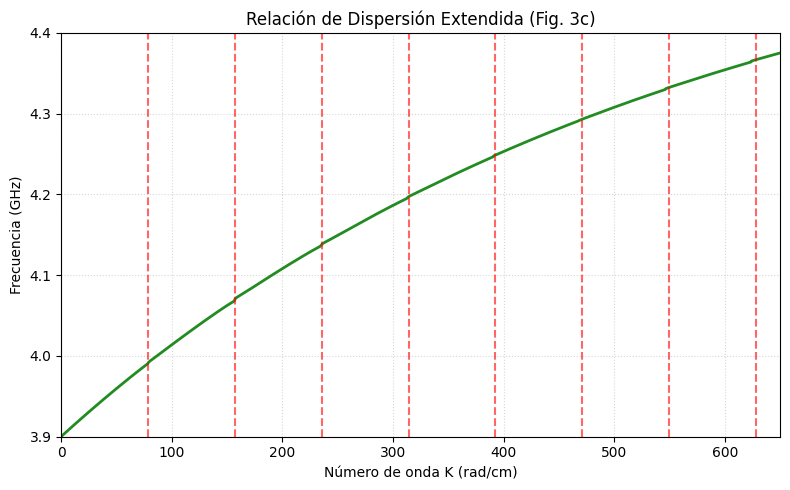

In [ ]:
# =================================================================
# 6. GRÁFICA CORREGIDA (Dispersión w vs K)
# =================================================================

n_zonas = 8
bz_boundaries = [(n * np.pi / Lambda) * 10000.0 for n in range(1, n_zonas + 1)]

plt.figure(figsize=(8, 5))

# Graficamos la curva desdoblada
plt.plot(K_array, f_disp_array, color='forestgreen', linewidth=2, label='Dispersión MSSW')

# Añadimos las líneas de la Zona de Brillouin
for bz in bz_boundaries:
    if bz <= 650:
        plt.axvline(x=bz, color='red', linestyle='--', alpha=0.6)

plt.title('Relación de Dispersión Extendida (Fig. 3c)')
plt.xlabel('Número de onda K (rad/cm)')
plt.ylabel('Frecuencia (GHz)')
plt.xlim(0, 650)
plt.ylim(3.9, 4.4)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Finalmente, combinamos ambos desarrollados en un sólo códico y ponemos ambas grafias en una sola figura para imitar la Fig. 3 del articulo.

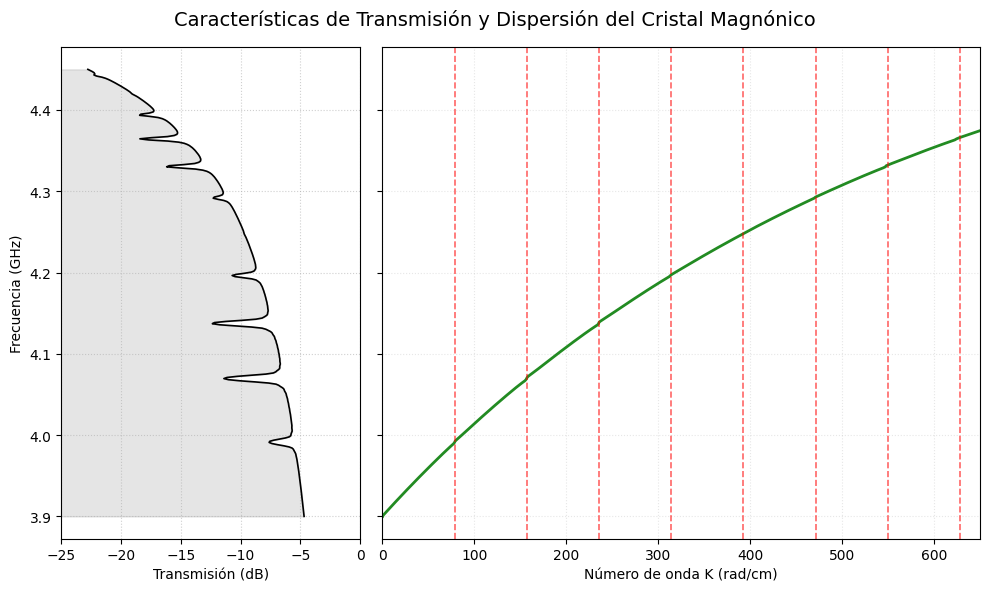

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================
gamma = 2.8
H0 = 770.0
Ms = 1750.0
deltaH = 0.5

wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM = 2 * np.pi * (gamma * Ms / 1000.0)

dPF = 8.3
delta = 1.0
dG = dPF - delta
LPF = 330.0
LG = 70.0
Lambda = LPF + LG
Nperiods = 12

# =================================================================
# 2. FUNCIONES DE DISPERSIÓN, MATRICES Y TRANSMISIÓN
# =================================================================
def k_wave(w, d):
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    return -(1 / (2 * d)) * np.log(arg)

def v_group(w, d):
    k = k_wave(w, d)
    return (wM**2 * d * np.exp(-2 * k * d)) / (4 * w)

def k_prime(w, d):
    vg = np.abs(v_group(w, d))
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / vg

GammaRef = delta / (2 * dPF - delta)

def T_interface(nu):
    mat = np.array([[1.0, nu * GammaRef], [nu * GammaRef, 1.0]], dtype=complex)
    return (1.0 / (1.0 - nu * GammaRef)) * mat

def T_prop(w, d, L):
    k = k_wave(w, d)
    kp = k_prime(w, d)
    return np.array([[np.exp(-(1j * k - kp) * L), 0.0],
                     [0.0, np.exp((1j * k - kp) * L)]], dtype=complex)

def T_cell(w):
    return T_prop(w, dPF, LPF) @ T_interface(1) @ T_prop(w, dG, LG) @ T_interface(-1)

# =================================================================
# 3. EVALUACIÓN NUMÉRICA (Transmisión y Vector de Bloch)
# =================================================================

# Frecuencias a evaluar (ajustadas para ver bien el detalle)
f_array = np.linspace(3.9, 4.45, 400)

trans_db = np.zeros(len(f_array))
raw_phis = np.zeros(len(f_array))

for i, f in enumerate(f_array):
    w = 2 * np.pi * f
    tc = T_cell(w)

    # 1. Cálculo de Transmisión
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    trans_db[i] = 10 * np.log10(1.0 / (np.abs(T11)**2))

    # 2. Cálculo de Fase (Dispersión cruda)
    tr = np.trace(tc)
    raw_phis[i] = np.real(np.arccos(tr / 2.0))

# Desdoblamiento de fase (Esquema de Zona Extendida)
K_extended_um = np.zeros(len(f_array))
K_extended_um[0] = raw_phis[0]
for i in range(1, len(f_array)):
    d_phi = np.abs(raw_phis[i] - raw_phis[i-1])
    K_extended_um[i] = K_extended_um[i-1] + d_phi

# Convertir a rad/cm
K_array = (K_extended_um / Lambda) * 10000.0

# Límites de la Zona de Brillouin
n_zonas = 8
bz_boundaries = [(n * np.pi / Lambda) * 10000.0 for n in range(1, n_zonas + 1)]

# =================================================================
# 4. CREACIÓN DE LA FIGURA COMPUESTA (Estilo Fig. 3 del artículo)
# =================================================================

# gridspec_kw permite que la gráfica de dispersión sea más ancha que la de transmisión
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 6),
                               gridspec_kw={'width_ratios': [1, 2]})

# --- PANEL IZQUIERDO: Transmisión (Fig 3b) ---
ax1.plot(trans_db, f_array, color='black', linewidth=1.2)
ax1.set_xlabel('Transmisión (dB)')
ax1.set_ylabel('Frecuencia (GHz)')
ax1.set_xlim(-25, 0)
ax1.grid(True, linestyle=':', alpha=0.6)

# sombreamos la zona de caída para darle mejor estética
ax1.fill_betweenx(f_array, trans_db, -75, color='gray', alpha=0.2)

# --- PANEL DERECHO: Dispersión (Fig 3c) ---
ax2.plot(K_array, f_array, color='forestgreen', linewidth=2)
ax2.set_xlabel('Número de onda K (rad/cm)')
ax2.set_xlim(0, 650)
ax2.grid(True, linestyle=':', alpha=0.3)

# Añadir fronteras de la zona de Brillouin
for bz in bz_boundaries:
    if bz <= 650:
        ax2.axvline(x=bz, color='red', linestyle='--', alpha=0.6, linewidth=1.2)

plt.suptitle('Características de Transmisión y Dispersión del Cristal Magnónico', fontsize=14)
plt.tight_layout()

# Quitar el espacio entre las dos gráficas para que se vean como un bloque
plt.subplots_adjust(wspace=0.05)
plt.show()